Imports PyTorch + torchvision (for CIFAR-10)

Imports DataLoader (to batch data)

Sets device to GPU if available

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch version:", torch.__version__)

Device: cuda
Torch version: 2.10.0+cu128


CIFAR-10 dataset

Downloads CIFAR-10 automatically into ./data

Creates:

train_set (50,000 images)

test_set (10,000 images)

Converts each image to a tensor using ToTensor()

Important: ToTensor() converts images from:

pixel range 0–255 → float range 0–1

shape becomes (C, H, W) = (3, 32, 32)

In [ ]:
# NO normalization, NO augmentation.
# Loading raw images first.
basic_transform = transforms.ToTensor()

train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=basic_transform
)

test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=basic_transform
)

print("Train size:", len(train_set))
print("Test size:", len(test_set))
print("Class names:", train_set.classes)

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


Train size: 50000
Test size: 10000
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


ONE data sample
x is the image tensor

y is the label (0–9)

x.shape = (3, 32, 32) means:

3 channels (RGB)

32x32 pixels

In [ ]:
x, y = train_set[0]  # first training example

print("x type:", type(x))
print("x shape:", x.shape)          # should be torch.Size([3, 32, 32])
print("x dtype:", x.dtype)          # float32
print("x min/max:", x.min().item(), x.max().item())

print("y:", y)
print("y class name:", train_set.classes[y])

x type: <class 'torch.Tensor'>
x shape: torch.Size([3, 32, 32])
x dtype: torch.float32
x min/max: 0.0 1.0
y: 6
y class name: frog


Display the image - visualize what CIFAR-10 looks like

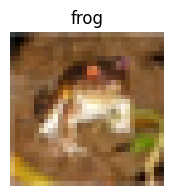

In [ ]:
def show_image(img_tensor, label):
    # img_tensor: (3, 32, 32)
    img = img_tensor.permute(1, 2, 0)  # (H, W, C) for matplotlib
    plt.figure(figsize=(2,2))
    plt.imshow(img)
    plt.title(train_set.classes[label])
    plt.axis("off")
    plt.show()

show_image(x, y)

Show a grid of multiple images---
CIFAR-10 is small images (32×32)---
Some classes look similar (cat vs dog), which is why it’s challenging

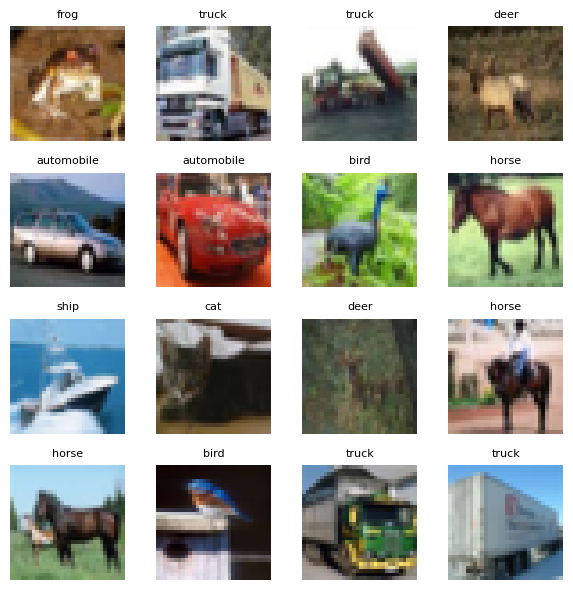

In [ ]:
def show_batch(dataset, n=16):
    plt.figure(figsize=(6,6))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)
        plt.subplot(4, 4, i+1)
        plt.imshow(img)
        plt.title(train_set.classes[label], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_set, n=16)

DataLoader

Instead of feeding 1 image at a time, training uses batches

xb.shape = (128, 3, 32, 32) means 128 images at once

In [ ]:
batch_size = 128

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch image shape:", xb.shape)  # (batch_size, 3, 32, 32)
print("Batch label shape:", yb.shape)  # (batch_size,)
print("First 10 labels:", yb[:10].tolist())

Batch image shape: torch.Size([128, 3, 32, 32])
Batch label shape: torch.Size([128])
First 10 labels: [7, 1, 6, 2, 1, 0, 8, 0, 3, 0]


check class balance

In [ ]:
from collections import Counter

labels = [train_set[i][1] for i in range(len(train_set))]
counts = Counter(labels)

for k in range(10):
    print(train_set.classes[k], ":", counts[k])

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


Flatten the image (turn 3×32×32 into 3072 numbers)

A fully connected network expects a 2D input: (batch, features)

CIFAR image (3,32,32) → 3*32*32 = 3072 features

Now you have (B, 3072)

In [ ]:

xb, yb = next(iter(train_loader))  # xb: (B, 3, 32, 32)

print("Before flatten:", xb.shape)

xb_flat = xb.view(xb.shape[0], -1)  # (B, 3072)

print("After flatten:", xb_flat.shape)
print("One image becomes length:", xb_flat.shape[1])

Before flatten: torch.Size([128, 3, 32, 32])
After flatten: torch.Size([128, 3072])
One image becomes length: 3072


Manual Fully Connected (Linear) layer

Creates parameters W and b

Forward: x @ W + b

Backward computes:

dW, db (how to change weights/bias)

dx (gradient to pass to previous layer)

In [ ]:
# Built in connected layer
# import torch
# import torch.nn as nn

# # Create built-in fully connected layer
# fc = nn.Linear(in_features=3072, out_features=256)

# # Example input (batch of 128 images flattened)
# x = torch.randn(128, 3072)

# # Forward pass
# out = fc(x)

# print("Output shape:", out.shape)

class Linear:
    def __init__(self, in_features, out_features, weight_scale=0.01, device="cpu"):
        self.W = weight_scale * torch.randn(in_features, out_features, device=device) # build it
        self.b = torch.zeros(out_features, device=device) # built in

        # gradients (filled during backward)
        self.dW = torch.zeros_like(self.W)
        self.db = torch.zeros_like(self.b)

        # cache input for backward
        self.x = None

    def forward(self, x):
        # x: (N, D)
        self.x = x
        return x @ self.W + self.b  # (N, M)

    def backward(self, dout):
        # dout: (N, M)
        self.dW = self.x.t() @ dout          # (D, M)
        self.db = dout.sum(dim=0)            # (M,)
        dx = dout @ self.W.t()               # (N, D)
        return dx

Manual ReLU

Forward: removes negatives

Backward: only passes gradient where input was positive


In [ ]:
class ReLU:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x > 0)
        return x * self.mask

    def backward(self, dout):
        return dout * self.mask

Softmax + Cross-Entropy loss

Converts logits → probabilities (softmax)

Computes loss (how wrong the model is)

Returns gradient dlogits which starts backprop

In [ ]:
def softmax(logits):
    # logits: (N, C)
    z = logits - logits.max(dim=1, keepdim=True).values  # stability trick
    exp = torch.exp(z)
    return exp / exp.sum(dim=1, keepdim=True)

def cross_entropy_loss_from_logits(logits, y):
    """
    logits: (N, C)
    y: (N,) integer labels
    returns: (loss scalar, dlogits)
    """
    N, C = logits.shape
    probs = softmax(logits)

    eps = 1e-12
    correct_probs = probs[torch.arange(N), y]  # probability of correct class
    loss = (-torch.log(correct_probs + eps)).mean()

    # gradient of loss w.r.t logits
    dlogits = probs.clone()
    dlogits[torch.arange(N), y] -= 1.0
    dlogits /= N
    return loss, dlogits

FC Neural Network model

Combines layers into a model

Forward produces logits

Backward propagates gradients through layers

params() returns all weights and gradients so we can update them


In [ ]:
class FCNet:
    def __init__(self, input_dim=3072, hidden_dim=256, num_classes=10, device="cpu"):
        self.fc1 = Linear(input_dim, hidden_dim, device=device)
        self.relu = ReLU()
        self.fc2 = Linear(hidden_dim, num_classes, device=device)

    def forward(self, x):
        # x: (N, 3, 32, 32)
        x = x.view(x.shape[0], -1)      # flatten
        x = self.fc1.forward(x)
        x = self.relu.forward(x)
        logits = self.fc2.forward(x)
        return logits

    def backward(self, dlogits):
        dx = self.fc2.backward(dlogits)
        dx = self.relu.backward(dx)
        dx = self.fc1.backward(dx)
        return dx

    def params(self):
        # return list of parameters and grads for updating
        return [
            (self.fc1.W, self.fc1.dW),
            (self.fc1.b, self.fc1.db),
            (self.fc2.W, self.fc2.dW),
            (self.fc2.b, self.fc2.db),
        ]

Manual gradient descent update

In [ ]:
def sgd_step(params, lr=0.1):
    for p, dp in params:
        p -= lr * dp

Accuracy function

In [ ]:
@torch.no_grad()
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

Training loop

Trains for multiple epochs

Each iteration:

forward

loss

backward

update

Stores:

loss_history (per batch/iteration)

train/test accuracy (per epoch)

In [ ]:
def train_fc(model, train_loader, test_loader, epochs=5, lr=0.1, device="cpu"):
    loss_history = []      # loss per iteration
    train_acc_hist = []    # train acc per epoch
    test_acc_hist = []     # test acc per epoch

    for epoch in range(1, epochs + 1):
        model_loss = 0.0
        model_acc = 0.0
        steps = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # forward
            logits = model.forward(xb)

            # loss + gradient start
            loss, dlogits = cross_entropy_loss_from_logits(logits, yb)

            # backward
            model.backward(dlogits)

            # update
            sgd_step(model.params(), lr=lr)

            # log
            loss_history.append(loss.item())
            model_loss += loss.item()
            model_acc += accuracy_from_logits(logits, yb)
            steps += 1

        # epoch summary
        train_acc = model_acc / steps
        train_acc_hist.append(train_acc)

        # test accuracy
        test_acc = evaluate(model, test_loader, device=device)
        test_acc_hist.append(test_acc)

        print(f"Epoch {epoch}: train_loss={model_loss/steps:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")

    return loss_history, train_acc_hist, test_acc_hist

@torch.no_grad()
def evaluate(model, loader, device="cpu"):
    acc_sum = 0.0
    steps = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model.forward(xb)
        acc_sum += accuracy_from_logits(logits, yb)
        steps += 1
    return acc_sum / steps

In [ ]:
model = FCNet(device=device)
loss_hist, train_acc_hist, test_acc_hist = train_fc(
    model, train_loader, test_loader,
    epochs=5, lr=0.1, device=device
)

Epoch 1: train_loss=1.9827 train_acc=0.2752 test_acc=0.3026
Epoch 2: train_loss=1.7893 train_acc=0.3607 test_acc=0.3615
Epoch 3: train_loss=1.7129 train_acc=0.3915 test_acc=0.3890
Epoch 4: train_loss=1.6595 train_acc=0.4127 test_acc=0.3909
Epoch 5: train_loss=1.6189 train_acc=0.4260 test_acc=0.4331


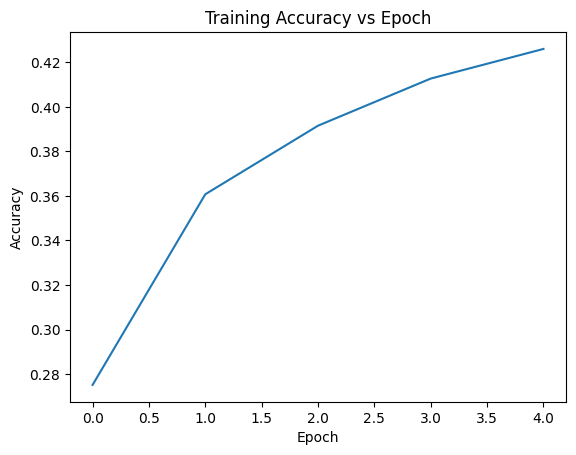

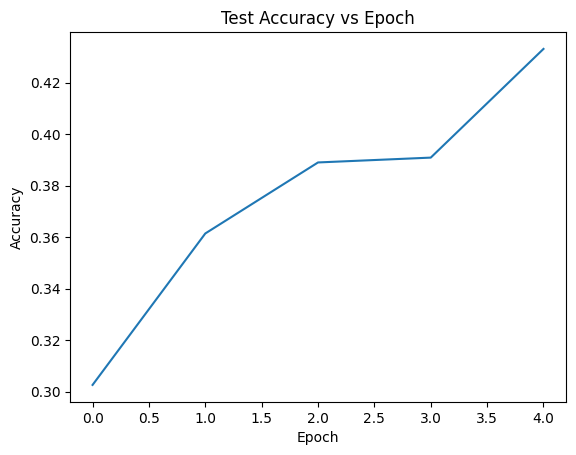

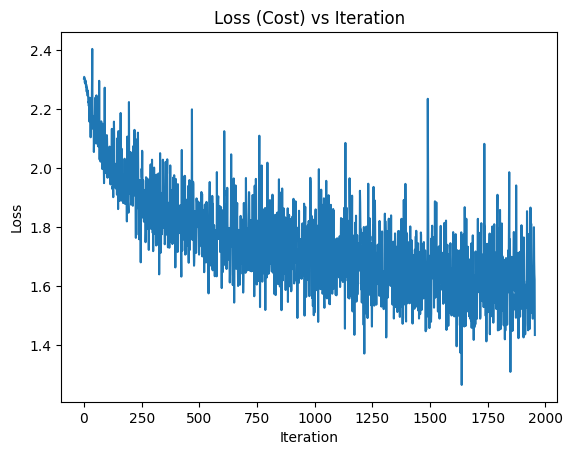

In [ ]:
# 1) Training accuracy vs epoch
plt.figure()
plt.plot(train_acc_hist)
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# 2) Test accuracy vs epoch
plt.figure()
plt.plot(test_acc_hist)
plt.title("Test Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# 3) Loss vs iteration
plt.figure()
plt.plot(loss_hist)
plt.title("Loss (Cost) vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

PlOT THE 3 required graphs

We did NOT use torch.nn.Linear, torch.nn.ReLU, torch.optim, CrossEntropyLoss

We only used:

DataLoader and CIFAR dataset (allowed)

Basic tensor operations (these are fine)

**L2 Regularization in Training** - **WEEK2**

In [ ]:
def train_fc_l2(model, train_loader, test_loader, epochs=5, lr=0.1, lambda_l2=0.001, device="cpu"):
    loss_history = []
    train_acc_hist = []
    test_acc_hist = []

    for epoch in range(1, epochs + 1):
        model_loss = 0.0
        model_acc = 0.0
        steps = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # forward pass
            logits = model.forward(xb)

            # cross-entropy loss
            loss, dlogits = cross_entropy_loss_from_logits(logits, yb)

            # backward pass
            model.backward(dlogits)

            # compute L2 penalty from weights
            l2_penalty = 0.0
            for param in model.params():
                w = param[0]          # first item in tuple = weights
                l2_penalty += torch.sum(w ** 2)

            total_loss = loss + lambda_l2 * l2_penalty

            # add L2 gradient manually
            for param in model.params():
                w = param[0]          # weights
                dw = param[1]         # gradient
                dw += 2 * lambda_l2 * w

            # update step
            sgd_step(model.params(), lr=lr)

            # logging
            loss_history.append(total_loss.item())
            model_loss += total_loss.item()
            model_acc += accuracy_from_logits(logits, yb)
            steps += 1

        train_acc = model_acc / steps
        train_acc_hist.append(train_acc)

        test_acc = evaluate(model, test_loader, device=device)
        test_acc_hist.append(test_acc)

        print(f"Epoch {epoch}: train_loss={model_loss/steps:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")

    return loss_history, train_acc_hist, test_acc_hist


L2 Regularization Experiment

We create a NEW model instance so it starts with fresh weights.
This ensures the L2 experiment is independent from the baseline model.

Train the model using L2 regularization.
lambda_l2 controls how strong the penalty is on large weights.
A small value (0.001) is commonly used to prevent overfitting.

In [ ]:
model_l2 = FCNet(device=device)

loss_hist_l2, train_acc_hist_l2, test_acc_hist_l2 = train_fc_l2(
    model_l2, train_loader, test_loader,
    epochs=5, lr=0.1, lambda_l2=0.001, device=device
)

Epoch 1: train_loss=2.0678 train_acc=0.2745 test_acc=0.3491
Epoch 2: train_loss=1.8840 train_acc=0.3527 test_acc=0.3792
Epoch 3: train_loss=1.8113 train_acc=0.3853 test_acc=0.3673
Epoch 4: train_loss=1.7703 train_acc=0.4012 test_acc=0.3816
Epoch 5: train_loss=1.7397 train_acc=0.4133 test_acc=0.3883


Training accuracy plot

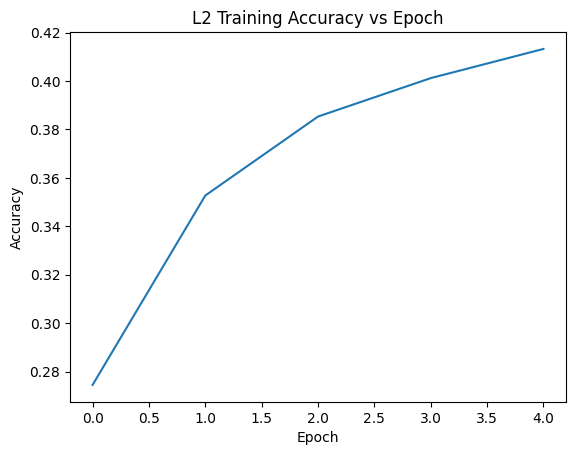

In [ ]:
# -------------------------------------------------------------
# Plot Training Accuracy for L2 Model
# Shows how the model performance improves across epochs
# -------------------------------------------------------------

plt.figure()
plt.plot(train_acc_hist_l2)
plt.title("L2 Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Test accuracy plot

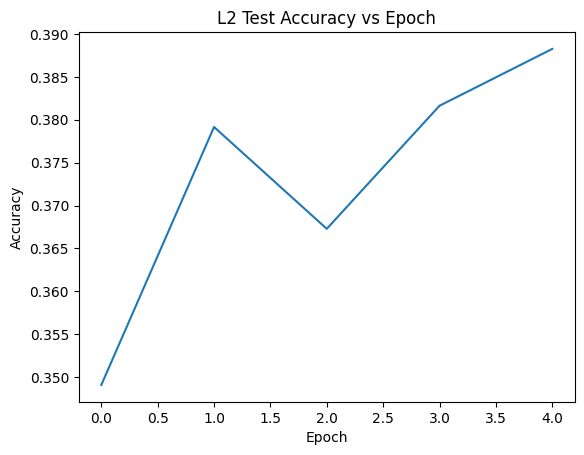

In [ ]:
# -------------------------------------------------------------
# Plot Test Accuracy for L2 Model
# This helps evaluate how well the model generalizes to unseen data
# -------------------------------------------------------------

plt.figure()
plt.plot(test_acc_hist_l2)
plt.title("L2 Test Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Loss plot

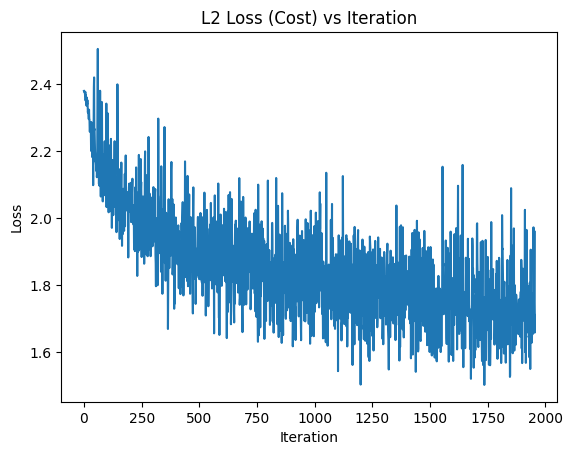

In [ ]:
# -------------------------------------------------------------
# Plot Loss vs Iteration for L2 Model
# Loss should generally decrease as training progresses
# -------------------------------------------------------------

plt.figure()
plt.plot(loss_hist_l2)
plt.title("L2 Loss (Cost) vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

**Dropout Function**

In [ ]:
# Manual Dropout Function
# Randomly drops some hidden activations during training
# p = probability of dropping a neuron
# -------------------------------------------------------------

def manual_dropout(x, p=0.5):
    mask = (torch.rand_like(x) > p).float()
    return x * mask / (1 - p), mask

Dropout model class

In [ ]:

# FCNet with Manual Dropout
# Input size is 32*32*3 = 3072 for CIFAR-10 images

class FCNetDropout:
    def __init__(self, input_dim=32*32*3, hidden_dim=128, output_dim=10, dropout_p=0.5, device="cpu"):
        self.device = device
        self.dropout_p = dropout_p

        # weights and biases
        self.W1 = 0.01 * torch.randn(input_dim, hidden_dim, device=device)
        self.b1 = torch.zeros(hidden_dim, device=device)

        self.W2 = 0.01 * torch.randn(hidden_dim, output_dim, device=device)
        self.b2 = torch.zeros(output_dim, device=device)

        # gradients
        self.dW1 = torch.zeros_like(self.W1)
        self.db1 = torch.zeros_like(self.b1)
        self.dW2 = torch.zeros_like(self.W2)
        self.db2 = torch.zeros_like(self.b2)

        # cache for backward pass
        self.x = None
        self.z1 = None
        self.a1 = None
        self.dropout_mask = None
        self.logits = None

    def forward(self, xb, training=True):
        x = xb.view(xb.shape[0], -1)

        z1 = x @ self.W1 + self.b1
        a1 = torch.relu(z1)

        # Apply dropout only during training
        if training:
            a1, self.dropout_mask = manual_dropout(a1, p=self.dropout_p)
        else:
            self.dropout_mask = None

        logits = a1 @ self.W2 + self.b2

        # Save values for backward
        self.x = x
        self.z1 = z1
        self.a1 = a1
        self.logits = logits

        return logits

    def backward(self, dlogits):
        batch_size = dlogits.shape[0]

        # Output layer gradients
        self.dW2 = self.a1.t() @ dlogits / batch_size
        self.db2 = dlogits.sum(dim=0) / batch_size

        # Backprop to hidden layer
        da1 = dlogits @ self.W2.t()

        # Apply dropout mask in backward pass
        if self.dropout_mask is not None:
            da1 = da1 * self.dropout_mask / (1 - self.dropout_p)

        dz1 = da1 * (self.z1 > 0).float()

        # Hidden layer gradients
        self.dW1 = self.x.t() @ dz1 / batch_size
        self.db1 = dz1.sum(dim=0) / batch_size

    def params(self):
        return [
            (self.W1, self.dW1),
            (self.b1, self.db1),
            (self.W2, self.dW2),
            (self.b2, self.db2),
        ]

Separate training function for dropout

In [ ]:
# Evaluate Dropout Model
# Dropout is OFF during testing/evaluation

@torch.no_grad()
def evaluate_dropout(model, loader, device="cpu"):
    acc_sum = 0.0
    steps = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model.forward(xb, training=False)

        acc_sum += accuracy_from_logits(logits, yb)
        steps += 1

    return acc_sum / steps

In [ ]:
# Training Function for Dropout Model
# Dropout is ON during training

def train_fc_dropout(model, train_loader, test_loader, epochs=5, lr=0.1, device="cpu"):
    loss_history = []
    train_acc_hist = []
    test_acc_hist = []

    for epoch in range(1, epochs + 1):
        model_loss = 0.0
        model_acc = 0.0
        steps = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # forward pass with dropout enabled
            logits = model.forward(xb, training=True)

            # loss and gradient
            loss, dlogits = cross_entropy_loss_from_logits(logits, yb)

            # backward pass
            model.backward(dlogits)

            # parameter update
            sgd_step(model.params(), lr=lr)

            # logging
            loss_history.append(loss.item())
            model_loss += loss.item()
            model_acc += accuracy_from_logits(logits, yb)
            steps += 1

        train_acc = model_acc / steps
        train_acc_hist.append(train_acc)

        test_acc = evaluate_dropout(model, test_loader, device=device)
        test_acc_hist.append(test_acc)

        print(f"Epoch {epoch}: train_loss={model_loss/steps:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")

    return loss_history, train_acc_hist, test_acc_hist

Dropout experiment

In [ ]:
# Dropout Experiment
# Create a NEW model so the experiment is independent
# dropout_p=0.5 means 50% of hidden neurons are dropped
# during training

model_dropout = FCNetDropout(device=device, dropout_p=0.2)

loss_hist_dropout, train_acc_hist_dropout, test_acc_hist_dropout = train_fc_dropout(
    model_dropout,
    train_loader,
    test_loader,
    epochs=5,
    lr=0.1,
    device=device
)

Epoch 1: train_loss=2.3016 train_acc=0.1014 test_acc=0.1259
Epoch 2: train_loss=2.2972 train_acc=0.1176 test_acc=0.1263
Epoch 3: train_loss=2.2923 train_acc=0.1194 test_acc=0.1277
Epoch 4: train_loss=2.2864 train_acc=0.1243 test_acc=0.1295
Epoch 5: train_loss=2.2790 train_acc=0.1312 test_acc=0.1366


Train

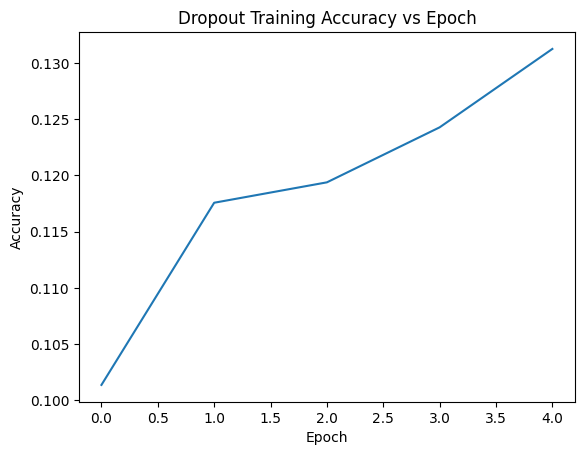

In [ ]:
plt.figure()
plt.plot(train_acc_hist_dropout)
plt.title("Dropout Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Test

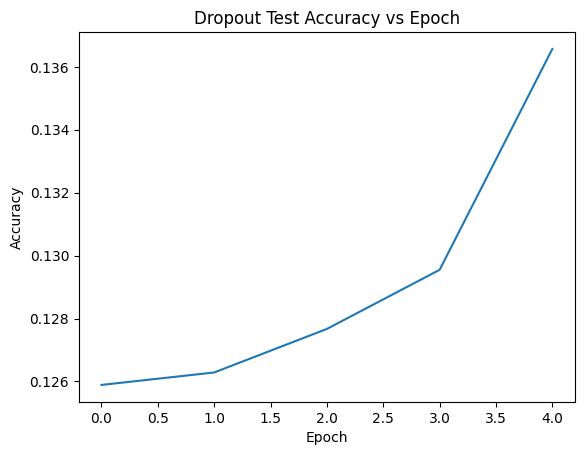

In [ ]:
plt.figure()
plt.plot(test_acc_hist_dropout)
plt.title("Dropout Test Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Loss

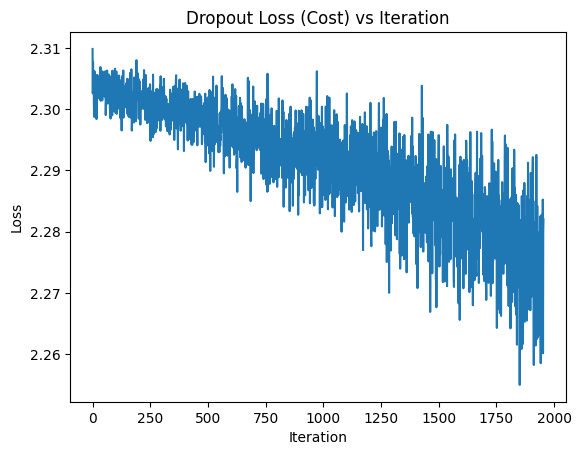

In [ ]:
plt.figure()
plt.plot(loss_hist_dropout)
plt.title("Dropout Loss (Cost) vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

Final Comparison

In [ ]:
print("===== Final Accuracy Comparison =====")
print(f"Baseline  - Train Acc: {train_acc_hist[-1]:.4f}, Test Acc: {test_acc_hist[-1]:.4f}")
print(f"L2        - Train Acc: {train_acc_hist_l2[-1]:.4f}, Test Acc: {test_acc_hist_l2[-1]:.4f}")
print(f"Dropout   - Train Acc: {train_acc_hist_dropout[-1]:.4f}, Test Acc: {test_acc_hist_dropout[-1]:.4f}")

===== Final Accuracy Comparison =====
Baseline  - Train Acc: 0.4260, Test Acc: 0.4331
L2        - Train Acc: 0.4133, Test Acc: 0.3883
Dropout   - Train Acc: 0.1312, Test Acc: 0.1366


**Week3**

**CNN - CIFAR-10 transforms and loaders**

In [ ]:
# DATASET FOR CNN
# Create new loaders for CNN experiments - We won't touch the first loader, we will use the other one for wk1 and wk2

cnn_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

cnn_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

cnn_train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=cnn_train_transform
)

cnn_test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=cnn_test_transform
)

cnn_train_loader = DataLoader(cnn_train_set, batch_size=128, shuffle=True)
cnn_test_loader = DataLoader(cnn_test_set, batch_size=128, shuffle=False)

print("CNN train size:", len(cnn_train_set))
print("CNN test size:", len(cnn_test_set))

CNN train size: 50000
CNN test size: 10000


Manual Momentum optimizer

In [ ]:
# Manual SGD with Momentum

class SGDMomentum:
    def __init__(self, params, lr=0.01, momentum=0.9):
        self.params = params
        self.lr = lr
        self.momentum = momentum

        self.velocities = []
        for p, dp in self.params:
            self.velocities.append(torch.zeros_like(p))

    def step(self):
        for i, (p, dp) in enumerate(self.params):
            self.velocities[i] = self.momentum * self.velocities[i] - self.lr * dp
            p += self.velocities[i]

Manual Adam optimizer

In [ ]:
# Manual Adam

class AdamManual:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0

        self.m = []
        self.v = []

        for p, dp in self.params:
            self.m.append(torch.zeros_like(p))
            self.v.append(torch.zeros_like(p))

    def step(self):
        self.t += 1

        for i, (p, dp) in enumerate(self.params):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * dp
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (dp ** 2)

            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

Learning rate decay functions

In [ ]:
import math

def cosine_lr(initial_lr, epoch, total_epochs):
    return initial_lr * 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))

def step_decay_lr(initial_lr, epoch, drop=0.5, every=10):
    return initial_lr * (drop ** (epoch // every))

Adding additonal comments so we have covered

Momentum

Adam

Cosine LR decay

Step LR decay

**CNN Model**

In [ ]:
# CNN MODEL

import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
# Helper function to get CNN parameters
# Convert PyTorch model params into your manual optimizer format

def get_model_params(model):
    params = []
    for p in model.parameters():
        if p.grad is not None:
            params.append((p.data, p.grad.data))
        else:
            params.append((p.data, torch.zeros_like(p.data)))
    return params

CNN accuracy function

In [ ]:
@torch.no_grad()
def evaluate_cnn(model, loader, device="cpu"):
    model.eval()
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == yb).sum().item()
        total += yb.size(0)

    return correct / total

CNN training loop with manual optimizer and LR decay

In [ ]:
def train_cnn_manual(model, train_loader, test_loader, optimizer_type="momentum",
                     scheduler_type=None, epochs=20, initial_lr=0.001, device="cpu"):

    criterion = nn.CrossEntropyLoss()

    train_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    lr_hist = []

    # create optimizer object later each epoch after grads exist
    optimizer = None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # set learning rate
        if scheduler_type == "cosine":
            current_lr = cosine_lr(initial_lr, epoch - 1, epochs)
        elif scheduler_type == "step":
            current_lr = step_decay_lr(initial_lr, epoch - 1, drop=0.5, every=10)
        else:
            current_lr = initial_lr

        lr_hist.append(current_lr)

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # zero gradients
            model.zero_grad()

            # forward
            logits = model(xb)
            loss = criterion(logits, yb)

            # backward
            loss.backward()

            # build manual optimizer using current gradients
            params = get_model_params(model)

            if optimizer_type == "momentum":
                if optimizer is None:
                    optimizer = SGDMomentum(params, lr=current_lr, momentum=0.9)
                else:
                    optimizer.params = params
                    optimizer.lr = current_lr

            elif optimizer_type == "adam":
                if optimizer is None:
                    optimizer = AdamManual(params, lr=current_lr)
                else:
                    optimizer.params = params
                    optimizer.lr = current_lr

            # manual update
            optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        test_acc = evaluate_cnn(model, test_loader, device=device)

        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        test_acc_hist.append(test_acc)

        print(f"Epoch {epoch}: lr={current_lr:.6f} train_loss={train_loss:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")

    return train_loss_hist, train_acc_hist, test_acc_hist, lr_hist

**Experiment 1: Momentum only**

In [ ]:
cnn_momentum = SimpleCNN().to(device)

loss_momentum, train_acc_momentum, test_acc_momentum, lr_momentum = train_cnn_manual(
    cnn_momentum,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="momentum",
    scheduler_type=None,
    epochs=20,
    initial_lr=0.01,
    device=device
)

Epoch 1: lr=0.010000 train_loss=2.1779 train_acc=0.1774 test_acc=0.3055
Epoch 2: lr=0.010000 train_loss=1.7793 train_acc=0.3349 test_acc=0.4425
Epoch 3: lr=0.010000 train_loss=1.5395 train_acc=0.4311 test_acc=0.4885
Epoch 4: lr=0.010000 train_loss=1.3877 train_acc=0.4921 test_acc=0.5665
Epoch 5: lr=0.010000 train_loss=1.2338 train_acc=0.5535 test_acc=0.6139
Epoch 6: lr=0.010000 train_loss=1.1080 train_acc=0.6017 test_acc=0.6554
Epoch 7: lr=0.010000 train_loss=1.0097 train_acc=0.6404 test_acc=0.6953
Epoch 8: lr=0.010000 train_loss=0.9154 train_acc=0.6757 test_acc=0.7217
Epoch 9: lr=0.010000 train_loss=0.8514 train_acc=0.7034 test_acc=0.7366
Epoch 10: lr=0.010000 train_loss=0.8036 train_acc=0.7188 test_acc=0.7573
Epoch 11: lr=0.010000 train_loss=0.7533 train_acc=0.7382 test_acc=0.7741
Epoch 12: lr=0.010000 train_loss=0.7152 train_acc=0.7512 test_acc=0.7628
Epoch 13: lr=0.010000 train_loss=0.6776 train_acc=0.7653 test_acc=0.7937
Epoch 14: lr=0.010000 train_loss=0.6552 train_acc=0.7723 tes

Experiment 2: Momentum + Cosine decay

In [ ]:
cnn_momentum_cosine = SimpleCNN().to(device)

loss_momentum_cosine, train_acc_momentum_cosine, test_acc_momentum_cosine, lr_momentum_cosine = train_cnn_manual(
    cnn_momentum_cosine,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="momentum",
    scheduler_type="cosine",
    epochs=20,
    initial_lr=0.01,
    device=device
)

Epoch 1: lr=0.010000 train_loss=2.2188 train_acc=0.1603 test_acc=0.2605
Epoch 2: lr=0.009938 train_loss=1.8270 train_acc=0.3254 test_acc=0.4134
Epoch 3: lr=0.009755 train_loss=1.5913 train_acc=0.4130 test_acc=0.4950
Epoch 4: lr=0.009455 train_loss=1.4195 train_acc=0.4828 test_acc=0.5114
Epoch 5: lr=0.009045 train_loss=1.2875 train_acc=0.5339 test_acc=0.5983
Epoch 6: lr=0.008536 train_loss=1.1593 train_acc=0.5870 test_acc=0.6431
Epoch 7: lr=0.007939 train_loss=1.0474 train_acc=0.6262 test_acc=0.6618
Epoch 8: lr=0.007270 train_loss=0.9675 train_acc=0.6555 test_acc=0.7017
Epoch 9: lr=0.006545 train_loss=0.8898 train_acc=0.6842 test_acc=0.7277
Epoch 10: lr=0.005782 train_loss=0.8337 train_acc=0.7056 test_acc=0.7391
Epoch 11: lr=0.005000 train_loss=0.7831 train_acc=0.7269 test_acc=0.7599
Epoch 12: lr=0.004218 train_loss=0.7380 train_acc=0.7419 test_acc=0.7710
Epoch 13: lr=0.003455 train_loss=0.7109 train_acc=0.7506 test_acc=0.7781
Epoch 14: lr=0.002730 train_loss=0.6751 train_acc=0.7652 tes

Experiment 3: Adam only

In [ ]:
cnn_adam = SimpleCNN().to(device)

loss_adam, train_acc_adam, test_acc_adam, lr_adam = train_cnn_manual(
    cnn_adam,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="adam",
    scheduler_type=None,
    epochs=20,
    initial_lr=0.001,
    device=device
)

Epoch 1: lr=0.001000 train_loss=1.7705 train_acc=0.3372 test_acc=0.4952
Epoch 2: lr=0.001000 train_loss=1.3509 train_acc=0.5084 test_acc=0.5954
Epoch 3: lr=0.001000 train_loss=1.1515 train_acc=0.5889 test_acc=0.6506
Epoch 4: lr=0.001000 train_loss=1.0220 train_acc=0.6367 test_acc=0.6874
Epoch 5: lr=0.001000 train_loss=0.9357 train_acc=0.6684 test_acc=0.7001
Epoch 6: lr=0.001000 train_loss=0.8634 train_acc=0.6962 test_acc=0.7100
Epoch 7: lr=0.001000 train_loss=0.8110 train_acc=0.7162 test_acc=0.7595
Epoch 8: lr=0.001000 train_loss=0.7547 train_acc=0.7393 test_acc=0.7644
Epoch 9: lr=0.001000 train_loss=0.7138 train_acc=0.7506 test_acc=0.7672
Epoch 10: lr=0.001000 train_loss=0.6895 train_acc=0.7602 test_acc=0.7866
Epoch 11: lr=0.001000 train_loss=0.6618 train_acc=0.7692 test_acc=0.7857
Epoch 12: lr=0.001000 train_loss=0.6403 train_acc=0.7789 test_acc=0.7713
Epoch 13: lr=0.001000 train_loss=0.6187 train_acc=0.7844 test_acc=0.7980
Epoch 14: lr=0.001000 train_loss=0.5979 train_acc=0.7941 tes

Experiment 4: Adam + Step decay

In [ ]:
cnn_adam_step = SimpleCNN().to(device)

loss_adam_step, train_acc_adam_step, test_acc_adam_step, lr_adam_step = train_cnn_manual(
    cnn_adam_step,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="adam",
    scheduler_type="step",
    epochs=20,
    initial_lr=0.001,
    device=device
)

Epoch 1: lr=0.001000 train_loss=1.7615 train_acc=0.3435 test_acc=0.4795
Epoch 2: lr=0.001000 train_loss=1.3803 train_acc=0.4988 test_acc=0.5715
Epoch 3: lr=0.001000 train_loss=1.1890 train_acc=0.5727 test_acc=0.6365
Epoch 4: lr=0.001000 train_loss=1.0510 train_acc=0.6267 test_acc=0.6883
Epoch 5: lr=0.001000 train_loss=0.9472 train_acc=0.6667 test_acc=0.7178
Epoch 6: lr=0.001000 train_loss=0.8668 train_acc=0.7000 test_acc=0.7295
Epoch 7: lr=0.001000 train_loss=0.8203 train_acc=0.7160 test_acc=0.7533
Epoch 8: lr=0.001000 train_loss=0.7588 train_acc=0.7378 test_acc=0.7609
Epoch 9: lr=0.001000 train_loss=0.7112 train_acc=0.7527 test_acc=0.7777
Epoch 10: lr=0.001000 train_loss=0.6784 train_acc=0.7666 test_acc=0.7776
Epoch 11: lr=0.000500 train_loss=0.6082 train_acc=0.7901 test_acc=0.8010
Epoch 12: lr=0.000500 train_loss=0.5830 train_acc=0.7999 test_acc=0.8048
Epoch 13: lr=0.000500 train_loss=0.5683 train_acc=0.8036 test_acc=0.8121
Epoch 14: lr=0.000500 train_loss=0.5547 train_acc=0.8076 tes

Plot test accuracy comparison

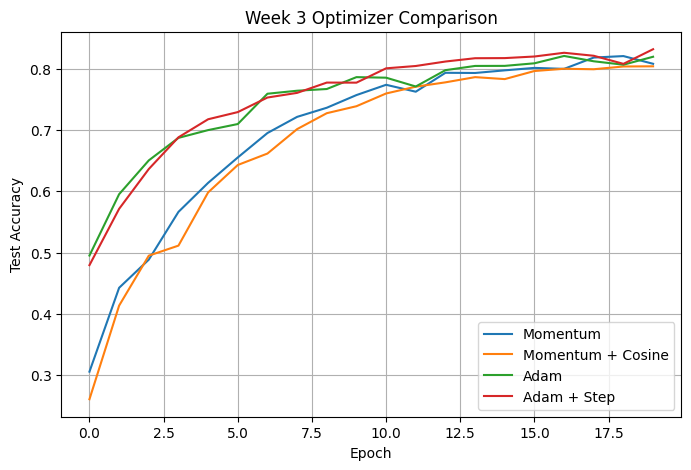

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(test_acc_momentum, label="Momentum")
plt.plot(test_acc_momentum_cosine, label="Momentum + Cosine")
plt.plot(test_acc_adam, label="Adam")
plt.plot(test_acc_adam_step, label="Adam + Step")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Week 3 Optimizer Comparison")
plt.legend()
plt.grid(True)
plt.show()

Plot training loss comparison

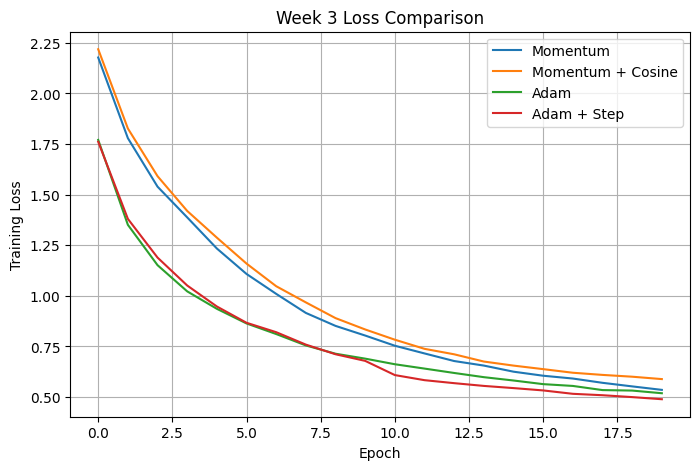

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_momentum, label="Momentum")
plt.plot(loss_momentum_cosine, label="Momentum + Cosine")
plt.plot(loss_adam, label="Adam")
plt.plot(loss_adam_step, label="Adam + Step")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Week 3 Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

Print best results from ablation study

In [ ]:
print("===== WEEK 3 OPTIMIZER COMPARISON =====")
print(f"Momentum best test acc:          {max(test_acc_momentum):.4f}")
print(f"Momentum + Cosine best test acc: {max(test_acc_momentum_cosine):.4f}")
print(f"Adam best test acc:              {max(test_acc_adam):.4f}")
print(f"Adam + Step best test acc:       {max(test_acc_adam_step):.4f}")

===== WEEK 3 OPTIMIZER COMPARISON =====
Momentum best test acc:          0.8210
Momentum + Cosine best test acc: 0.8043
Adam best test acc:              0.8212
Adam + Step best test acc:       0.8322


Final best model run for 75%+

In [ ]:
best_cnn = SimpleCNN().to(device)

best_loss, best_train_acc, best_test_acc, best_lr = train_cnn_manual(
    best_cnn,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="adam",
    scheduler_type="cosine",
    epochs=30,
    initial_lr=0.001,
    device=device
)

Epoch 1: lr=0.001000 train_loss=1.7222 train_acc=0.3619 test_acc=0.5018
Epoch 2: lr=0.000997 train_loss=1.3426 train_acc=0.5112 test_acc=0.5850
Epoch 3: lr=0.000989 train_loss=1.1511 train_acc=0.5868 test_acc=0.6381
Epoch 4: lr=0.000976 train_loss=1.0089 train_acc=0.6428 test_acc=0.6700
Epoch 5: lr=0.000957 train_loss=0.9112 train_acc=0.6787 test_acc=0.7289
Epoch 6: lr=0.000933 train_loss=0.8401 train_acc=0.7062 test_acc=0.7483
Epoch 7: lr=0.000905 train_loss=0.7786 train_acc=0.7289 test_acc=0.7623
Epoch 8: lr=0.000872 train_loss=0.7376 train_acc=0.7425 test_acc=0.7770
Epoch 9: lr=0.000835 train_loss=0.6967 train_acc=0.7564 test_acc=0.7841
Epoch 10: lr=0.000794 train_loss=0.6651 train_acc=0.7672 test_acc=0.7895
Epoch 11: lr=0.000750 train_loss=0.6365 train_acc=0.7772 test_acc=0.7911
Epoch 12: lr=0.000703 train_loss=0.6075 train_acc=0.7892 test_acc=0.7941
Epoch 13: lr=0.000655 train_loss=0.5852 train_acc=0.7960 test_acc=0.8090
Epoch 14: lr=0.000604 train_loss=0.5639 train_acc=0.8045 tes

Final plot

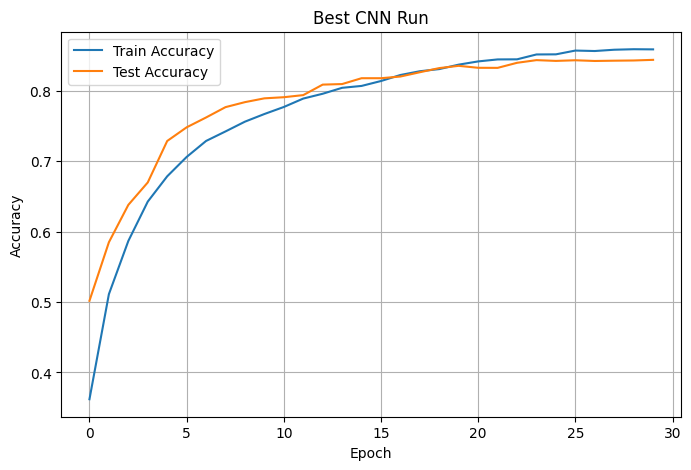

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(best_train_acc, label="Train Accuracy")
plt.plot(best_test_acc, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Best CNN Run")
plt.legend()
plt.grid(True)
plt.show()

Final result print

In [ ]:
print("Final Best Test Accuracy:", max(best_test_acc))

Final Best Test Accuracy: 0.8442
